In [1]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [3]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 128
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}


(-0.2, 10.2)

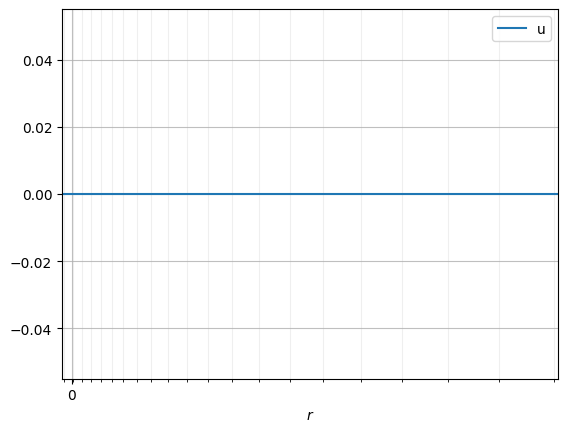

In [4]:
initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

#plot initial conditions
plt.xlabel('r')
plt.plot(r, initial_u, label='u')
#plt.plot(r, initial_v, label='v')
#plt.plot(r, initial_arr, label='arr')
#plt.plot(r, initial_att, label='att')
#plt.plot(r, initial_K, label='K')
#plt.plot(r, initial_phi, label='phi')
#plt.plot(r, initial_hrr, '.', label='hrr') # zero, but plot as dots to see the grid
#plt.plot(r, initial_lapse, label='lapse')
#plt.plot(r, initial_lambdar, label='lambdar')
plt.legend(loc='best')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,10.2)
#plt.ylim(-0.001,0.001)

In [5]:
# check the Hamiltonian and momentum constraints are initially satisfied
#Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)

# plot the profile for Ham
#plt.plot(r, Ham[0])
#plt.plot(r, Mom[0])

#plt.xlabel('r')
#plt.ylabel('Ham value')
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)
#plt.xlim(-0.5,R+2)
#plt.ylim(-0.1,0.1)

In [6]:
# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

'''# check the Hamiltonian and momentum constraints are initially satisfied
Ham_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)

# plot the profiles for Ham
plt.plot(r, Ham[0],'--',label="LR Ham")
plt.plot(r_HR, Ham_HR[0],'-',label="HR Ham")
plt.plot(r_HR, Ham_HR[0] * 2.0**4.0,':',label="LR Ham predicted by 4th order convergence")

plt.xlabel('r')
plt.ylabel('Ham value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0.0,2)
plt.ylim(-0.0001,0.0001)
plt.legend();'''

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


'# check the Hamiltonian and momentum constraints are initially satisfied\nHam_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)\n\n# plot the profiles for Ham\nplt.plot(r, Ham[0],\'--\',label="LR Ham")\nplt.plot(r_HR, Ham_HR[0],\'-\',label="HR Ham")\nplt.plot(r_HR, Ham_HR[0] * 2.0**4.0,\':\',label="LR Ham predicted by 4th order convergence")\n\nplt.xlabel(\'r\')\nplt.ylabel(\'Ham value\')\nax = plt.gcf().gca()\nset_grid_on_ax(ax, r)\nplt.xlim(0.0,2)\nplt.ylim(-0.0001,0.0001)\nplt.legend();'

In [7]:
# find the apparent horizon for a given set of states
'''omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)

# plot the null expansion omega and its zero crossing
plt.plot(r, omega[0])
plt.axvline(x=ah_radius[0],c="k",label="BH horizon")
plt.xlabel('r')
plt.ylabel('Expansion of null geodesics')
plt.legend(loc="best")
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0,3)
#plt.ylim(-0.1,0.1)

print("horizon is at r =", round(ah_radius[0],1))'''

'omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)\n\n# plot the null expansion omega and its zero crossing\nplt.plot(r, omega[0])\nplt.axvline(x=ah_radius[0],c="k",label="BH horizon")\nplt.xlabel(\'r\')\nplt.ylabel(\'Expansion of null geodesics\')\nplt.legend(loc="best")\nax = plt.gcf().gca()\nset_grid_on_ax(ax, r)\nplt.xlim(0,3)\n#plt.ylim(-0.1,0.1)\n\nprint("horizon is at r =", round(ah_radius[0],1))'

In [8]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 20
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 100

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

# Evolution of scalar field 

In [9]:
inta = 0
for i in range(len(my_state_vector.VARIABLE_NAMES)):
    print('Index: ', inta, 'Variable Name: ',  my_state_vector.VARIABLE_NAMES[i])
    inta = inta +1

Index:  0 Variable Name:  phi
Index:  1 Variable Name:  hrr
Index:  2 Variable Name:  htt
Index:  3 Variable Name:  hpp
Index:  4 Variable Name:  K
Index:  5 Variable Name:  arr
Index:  6 Variable Name:  att
Index:  7 Variable Name:  app
Index:  8 Variable Name:  lambdar
Index:  9 Variable Name:  shiftr
Index:  10 Variable Name:  br
Index:  11 Variable Name:  lapse
Index:  12 Variable Name:  u
Index:  13 Variable Name:  v


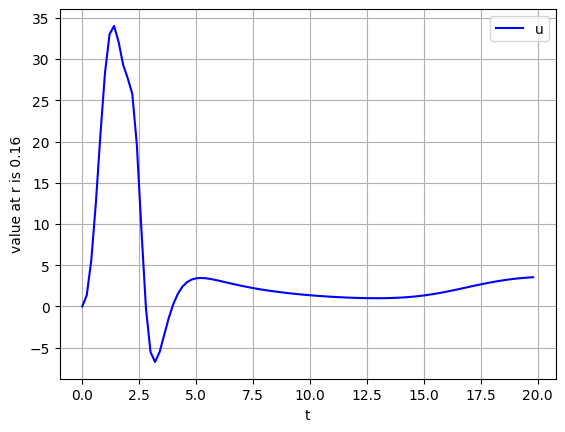

In [10]:
# Plot a single point versus time
idx_u = 12

var1 = idx_u

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

# Evolution of variables (lapse, shift, K, ...)

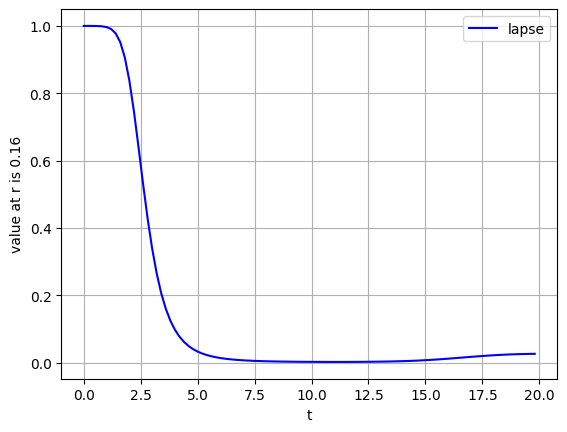

In [11]:
# Plot a single point versus time
idx_u = 12

var1 = idx_lapse

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

## Different variables at different radii and different times

(-10.0, 10.0)

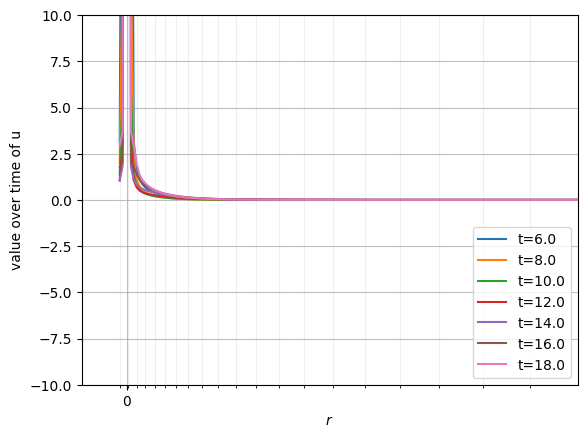

In [12]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 



var = 12
for i, t_i in enumerate(t) :
    if (i < 250) and (i % 10 == 0) and (t_i > 5.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-1,10)
plt.ylim(-10,10)

In [13]:
# calculate the diagnostics, just the Hamiltonian constraint for now
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)

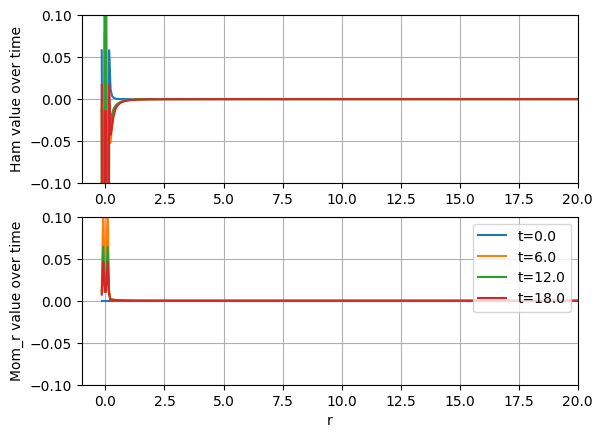

In [14]:
# plot the profile for Ham and Mom at a selection of times

for i, t_i in enumerate(t) :
    if (i < num_points_t) and (i % 30 == 0) :
        labelt = "t="+str(round(t_i,2))
        Ham_t = Ham[i,:]
        ax1 = plt.subplot(211)
        plt.plot(r, Ham_t, label=labelt)
        ax2 = plt.subplot(212)
        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)
        plt.plot(r, Mom_t, label=labelt)

plt.legend()
ax2.set_xlabel('r')
ax1.set_ylabel('Ham value over time')
ax1.set_xlim(-1,20.0)
ax1.set_ylim(-0.1,0.1)
ax1.grid()
ax2.set_ylabel('Mom_r value over time')
ax2.set_xlim(-1,20.0)
ax2.set_ylim(-0.1,0.1)
ax2.grid()

# AH finder

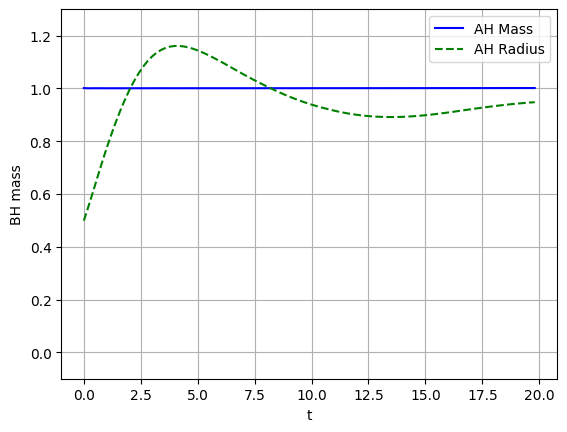

In [15]:
# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

plt.plot(t, bh_mass, 'b-', label="AH Mass")
plt.plot(t, ah_radius, 'g--', label="AH Radius")
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('BH mass')
plt.legend(loc='best')
plt.ylim(-0.1,1.3)

#print('t: ', t)
#print('R_{AH}: ', ah_radius)
#print(len(ah_radius))



plt.grid()

# Scalar field evolution at AH

In [16]:
interpolated_u_of_r_at_different_times = []

for timepoint in range(len(t)):
    interpolated_u_of_r_at_different_times.append(interp1d(r,solution[timepoint, var * num_points: (var + 1) * num_points],  kind='cubic', fill_value='extrapolate'))
    
# This is a list of all of the interpolation functions (function of value of u in terms value of r [gotten in an interpolated way]) at all the different time steps
#print(interpolated_u_of_r_at_different_times)


In [17]:
u_of_ahR = []

for idx_ahr, ahr in enumerate(ah_radius):
    u_of_ahR.append(interpolated_u_of_r_at_different_times[idx_ahr](ahr))
    
#print(u_of_ahR)
    
    

final value of scalar field:  0.24936652786159164


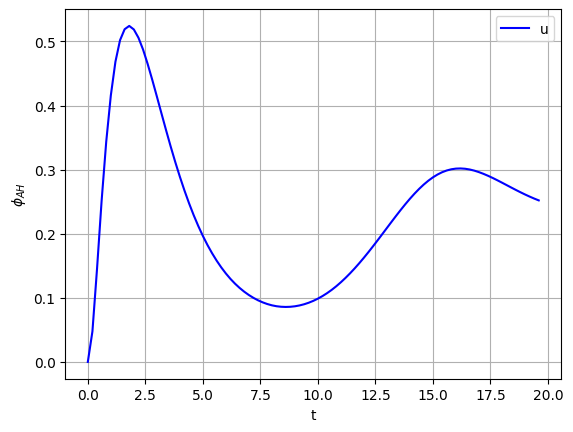

In [23]:
maxidx = 99

plt.plot(t[:maxidx], u_of_ahR[:maxidx], 'b-', label='u')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('$\phi_{AH}$')
plt.legend(loc='best')
plt.grid()

print('final value of scalar field: ', u_of_ahR[maxidx])

# Kretschmann scalar VS LGB term

The coordinate transformation to go from Schwarzschild ($r$) to isotropic ($R$) coordinates

$r = \frac{(1+M)^2}{4R}$

In Schwarzschil coordinates the K scalar is given by

$K = \frac{48}{r^6}$

Hence what we need

$K = \frac{48}{\left(\frac{(1+M)^2}{4R}\right)^6}$

The K scalar is equal to the GB term at first order (if we neglect backreaction)

 

In [24]:
# Value of the Gauss Bonnet term at the first time slice 

GB_vals = [
    4.06503854e-30, 1.63726804e-28, 9.70869286e-29, 3.16320330e+04, 4.71670249e+04,
    6.62324684e+03, 3.10083334e+03, 1.59644118e+03, 9.05470108e+02, 5.50691848e+02,
    3.52670286e+02, 2.34957192e+02, 1.61473768e+02, 1.13777314e+02, 8.18219650e+01,
    5.98453610e+01, 4.43973201e+01, 3.33360068e+01, 2.52901169e+01, 1.93580009e+01,
    1.49329442e+01, 1.15983504e+01, 9.06303456e+00, 7.12024892e+00, 5.62114211e+00,
    4.45721342e+00, 3.54849893e+00, 2.83548372e+00, 2.27348085e+00, 1.82867095e+00,
    1.47527679e+00, 1.19352450e+00, 9.68157258e-01, 7.87341244e-01, 6.41853550e-01,
    5.24474525e-01, 4.29529842e-01, 3.52543130e-01, 2.89970882e-01, 2.38999043e-01,
    1.97386140e-01, 1.63341741e-01, 1.35431883e-01, 1.12505200e-01, 9.36350098e-02,
    7.80737466e-02, 6.52170113e-02, 5.45751111e-02, 4.57504737e-02, 3.84196728e-02,
    3.23190892e-02, 2.72334442e-02, 2.29866100e-02, 1.94342287e-02, 1.64577712e-02,
    1.39597459e-02, 1.18598274e-02, 1.00917215e-02, 8.60062354e-03, 7.34115247e-03,
    6.27566947e-03, 5.37290712e-03, 4.60684973e-03, 3.95581739e-03, 3.40171540e-03,
    2.92941827e-03, 2.52626338e-03, 2.18163405e-03, 1.88661578e-03, 1.63371239e-03,
    1.41661120e-03, 1.22998854e-03, 1.06934843e-03, 9.30888575e-04, 8.11388829e-04,
    7.08118342e-04, 6.18758045e-04, 5.41335909e-04, 4.74172775e-04, 4.15836977e-04,
    3.65106270e-04, 3.20935852e-04, 2.82431461e-04, 2.48826727e-04, 2.19464051e-04,
    1.93778483e-04, 1.71284068e-04, 1.51562302e-04, 1.34252336e-04, 1.19042671e-04,
    1.05664094e-04, 9.38836671e-05, 8.34996151e-05, 7.43369569e-05, 6.62437798e-05,
    5.90880534e-05, 5.27549029e-05, 4.71442729e-05, 4.21689230e-05, 3.77527071e-05,
    3.38290938e-05, 3.03398927e-05, 2.72341575e-05, 2.44672397e-05, 2.19999713e-05,
    1.97979589e-05, 1.78309723e-05, 1.60724156e-05, 1.44988679e-05, 1.30896856e-05,
    1.18266559e-05, 1.06936964e-05, 9.67659306e-06, 8.76277178e-06, 7.94109985e-06,
    7.20171200e-06, 6.53585866e-06, 5.93577329e-06, 5.39455615e-06, 4.90607251e-06,
    4.46486342e-06, 4.06606734e-06, 3.70535134e-06, 3.37885056e-06, 3.08311501e-06,
    2.81506264e-06, 2.57193806e-06, 2.35127599e-06, 2.15086919e-06, 1.96873991e-06,
    1.80311480e-06, 1.65240264e-06, 1.51517462e-06, 1.39014688e-06, 1.27616496e-06,
    1.17219014e-06, 1.07728710e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00
]

In [25]:
# To obtain the scalar K in iso SZ coordinates

def iso_to_sz(R):
    r = R*(1+ (1/2*R))**2
    return r

def Kretschmann(r):
    Kr = 48/r**6
    return Kr



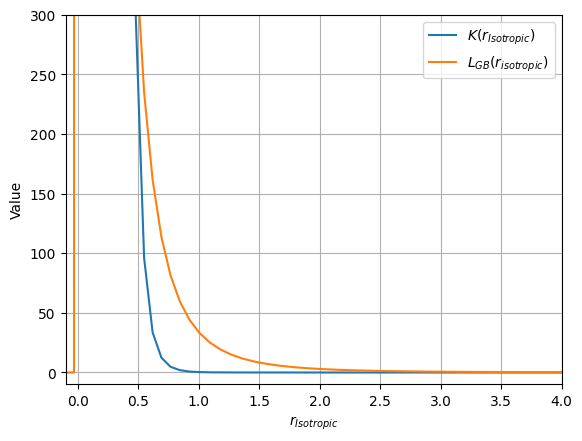

In [26]:


#plt.plot(sz_r, Kretschmann(sz_r), label='K')
#plt.plot(sz_r, GB_vals, label = 'GB_Term')

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$')
plt.plot(r, GB_vals, label = '$L_{GB} (r_{isotropic})$')


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
plt.xlim(-0.1,4)
plt.ylim(-10,300)
plt.grid()

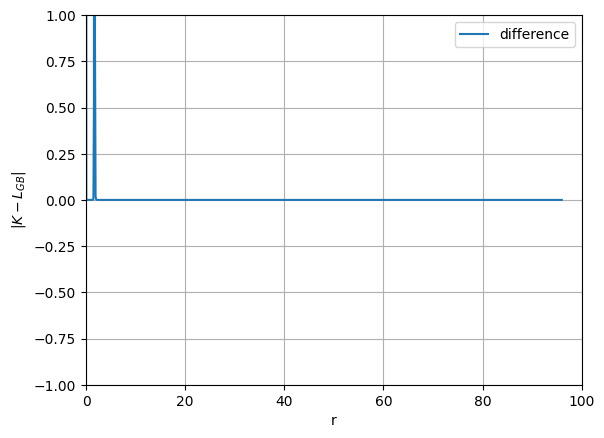

In [18]:
reldiff = np.abs(Kretschmann(iso_to_sz(r) - GB_vals))

plt.plot(r, reldiff , label='difference')
plt.legend(loc='best')
plt.xlabel('r')
plt.ylabel('$|K - L_{GB}|$')
plt.legend(loc='best')
plt.xlim(-0.10,100)
plt.ylim(-1,1)
plt.grid()